<a href="https://colab.research.google.com/github/hishamsharif/lmu-ai-vision-dl-assessment/blob/master/PPE_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS7002NU Assessment 1 — PPE Detection System
**London Building Materials Manufacturing Ltd.**

Computer vision system to detect PPE compliance (helmets, hi-vis vests, goggles) from factory camera feeds.

| Layer | Tool |
|-------|------|
| Code | GitHub (`lmu-ai-vision-dl-assessment`) |
| Compute | Google Colab T4 GPU |
| Storage | Google Drive (`MyDrive/CS7002NU_PPE/`) |

## 0. Environment Setup
Mount Google Drive, clone the GitHub repo, install dependencies, add `src/` to path.

> **Run this cell first on every new Colab session.**

In [18]:
import os, sys

# 1. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT    = '/content/drive/MyDrive/CS7002NU_PPE'
DATASET_DIR   = f'{DRIVE_ROOT}/datasets'
SECTION_A_DIR = f'{DATASET_DIR}/section_a'
SECTION_B_DIR = f'{DATASET_DIR}/section_b/raw'
OUTPUT_DIR    = f'{DRIVE_ROOT}/outputs'

for d in [SECTION_A_DIR, f'{SECTION_B_DIR}/train', f'{SECTION_B_DIR}/valid',
          f'{OUTPUT_DIR}/section_a', f'{OUTPUT_DIR}/section_b']:
    os.makedirs(d, exist_ok=True)

# 2. Clone / pull GitHub repo (always pulls latest on every run)
REPO_URL = 'https://github.com/hishamsharif/lmu-ai-vision-dl-assessment.git'
REPO_DIR = '/content/lmu-ai-vision-dl-assessment'
if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    !git -C {REPO_DIR} pull
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# Clear cached src.* imports so updated modules are reloaded after git pull
for mod in list(sys.modules.keys()):
    if mod.startswith('src'):
        del sys.modules[mod]

# 3. Install dependencies
!pip install -q opencv-python-headless gdown

# 4. Verify
import cv2, numpy as np, matplotlib
print('cv2    :', cv2.__version__)
print('numpy  :', np.__version__)
print('Setup complete')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
remote: Enumerating objects: 1, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 1 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (1/1), 928 bytes | 928.00 KiB/s, done.
From https://github.com/hishamsharif/lmu-ai-vision-dl-assessment
   a2515e9..f1a3077  master     -> origin/master
Updating a2515e9..f1a3077
Fast-forward
 PPE_Detection.ipynb | 102 ++++++++++++++++++----------------------------------
 1 file changed, 34 insertions(+), 68 deletions(-)
cv2    : 4.13.0
numpy  : 2.0.2
Setup complete


## 1. Dataset Download
Downloads and extracts the assessment image datasets from publicly shared Google Drive links.
Each download runs **once** — a guard check skips it on subsequent Colab sessions if the data
is already present on Drive.

| Dataset | Contents | Drive link |
|---------|----------|------------|
| `section_a.zip` | Image A, Image B, Image C | Public (no auth required) |
| `section_b.zip` | YOLO PPE dataset — train / valid splits | Public (no auth required) |

In [19]:
from src.utils.download import download_datasets

paths = download_datasets(DATASET_DIR)

SECTION_A_DIR = paths['section_a']
SECTION_B_DIR = os.path.join(paths['section_b'], 'raw')

print('section_a ->', SECTION_A_DIR)
print('section_b ->', SECTION_B_DIR)

Downloading...
From: https://drive.google.com/uc?id=1qhq55YpJr6kLiMiURJtsUEQQkvHtWyKv
To: /tmp/section_a.zip
100%|██████████| 216k/216k [00:00<00:00, 81.4MB/s]

[section_a] extracted -> /content/drive/MyDrive/CS7002NU_PPE/datasets/section_a
[section_b] already on Drive — skipping download
section_a -> /content/drive/MyDrive/CS7002NU_PPE/datasets/section_a
section_b -> /content/drive/MyDrive/CS7002NU_PPE/datasets/section_b/raw


---
## Section A: Image Processing

### A.1 Image Blending
Blend Image A and Image B using three alpha weight ratios: **0.60/0.40**, **0.75/0.25**, **0.50/0.50**.

Formula: `output(x,y) = α · imgA(x,y) + (1 − α) · imgB(x,y)`

Implementation: `cv2.addWeighted(imgA, α, imgB, 1−α, gamma=0)`

In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from src.section_a.image_ops import blend

img_a = cv2.imread(f'{SECTION_A_DIR}/Image_A.jpeg')
img_b = cv2.imread(f'{SECTION_A_DIR}/Image_B.jpeg')
assert img_a is not None, f'Image_A.jpeg not found in {SECTION_A_DIR}'
assert img_b is not None, f'Image_B.jpeg not found in {SECTION_A_DIR}'
print(f'Image A: {img_a.shape}   Image B: {img_b.shape}')

Image A: (316, 316, 3)   Image B: (700, 700, 3)


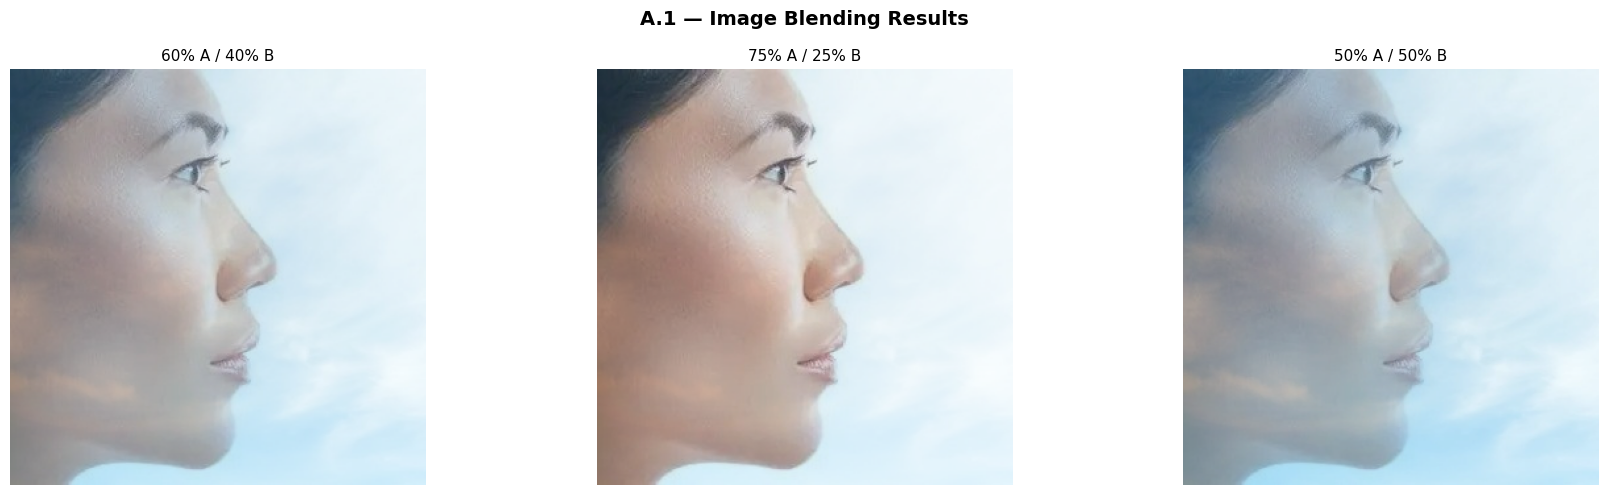

Saved -> /content/drive/MyDrive/CS7002NU_PPE/outputs/section_a/blending_results.png


In [21]:
alphas = [0.60, 0.75, 0.50]
labels = ['60% A / 40% B', '75% A / 25% B', '50% A / 50% B']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('A.1 — Image Blending Results', fontsize=14, fontweight='bold')

for ax, alpha, label in zip(axes, alphas, labels):
    result = blend(img_a, img_b, alpha)
    ax.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    ax.set_title(label, fontsize=11)
    ax.axis('off')

plt.tight_layout()
out = f'{OUTPUT_DIR}/section_a/blending_results.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', out)

#### Analysis — Image Blending

**Effect of alpha weights:**  
The `alpha` parameter directly controls which image dominates the output. At `α=0.75` Image A
contributes 75% of each pixel's intensity, making it the visually dominant layer. At `α=0.50`
both images contribute equally, producing a semi-transparent composite. The formula
`α·A + (1−α)·B` ensures pixel values remain in the valid [0, 255] range since both weights
sum to 1.0.

**CV preprocessing relevance:**  
Image blending is directly related to **MixUp augmentation**, a widely used deep learning
regularisation technique where two training images and their labels are blended with a random
alpha drawn from a Beta distribution. This forces the CNN to learn smoother decision boundaries
and improves generalisation on unseen data. In the factory context, blending a reference
(PPE-compliant) frame with a live feed frame could also be used to synthesise training examples
that simulate partial PPE occlusion.

### A.2 Histogram Equalisation
Apply histogram equalisation to Image C to improve contrast under uneven factory floor lighting.

Algorithm: remap pixel intensities via the cumulative distribution function (CDF) to span the full 0–255 range.

Implementation: `cv2.equalizeHist()` on grayscale channel.

/tmp/ipykernel_4016/2977837990.py:20: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 0].hist(gray_orig.ravel(), 256, [0, 256], color='steelblue')
/tmp/ipykernel_4016/2977837990.py:23: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(gray_eq.ravel(), 256, [0, 256], color='darkorange')


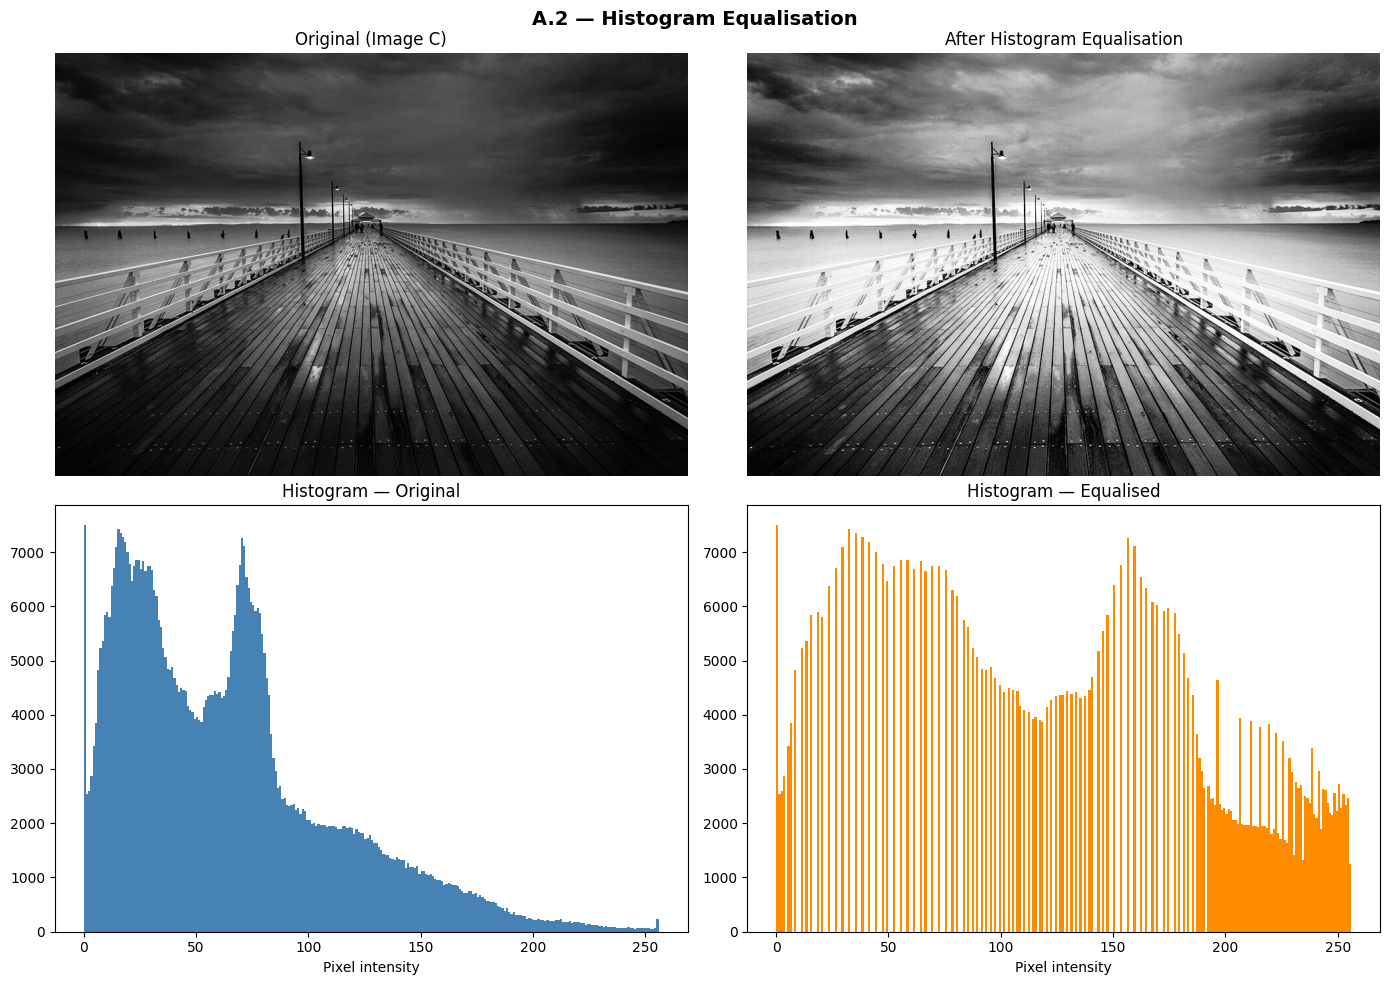

Saved -> /content/drive/MyDrive/CS7002NU_PPE/outputs/section_a/histogram_equalisation.png


In [22]:
from src.section_a.image_ops import equalize_histogram

img_c = cv2.imread(f'{SECTION_A_DIR}/Image_C.jpeg')
assert img_c is not None, f'Image_C.jpeg not found in {SECTION_A_DIR}'

img_c_eq = equalize_histogram(img_c)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('A.2 — Histogram Equalisation', fontsize=14, fontweight='bold')

axes[0, 0].imshow(cv2.cvtColor(img_c, cv2.COLOR_BGR2RGB))
axes[0, 0].set_title('Original (Image C)'); axes[0, 0].axis('off')

axes[0, 1].imshow(cv2.cvtColor(img_c_eq, cv2.COLOR_BGR2RGB))
axes[0, 1].set_title('After Histogram Equalisation'); axes[0, 1].axis('off')

gray_orig = cv2.cvtColor(img_c, cv2.COLOR_BGR2GRAY)
gray_eq   = cv2.cvtColor(img_c_eq, cv2.COLOR_BGR2GRAY)

axes[1, 0].hist(gray_orig.ravel(), 256, [0, 256], color='steelblue')
axes[1, 0].set_title('Histogram — Original'); axes[1, 0].set_xlabel('Pixel intensity')

axes[1, 1].hist(gray_eq.ravel(), 256, [0, 256], color='darkorange')
axes[1, 1].set_title('Histogram — Equalised'); axes[1, 1].set_xlabel('Pixel intensity')

plt.tight_layout()
out = f'{OUTPUT_DIR}/section_a/histogram_equalisation.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', out)

#### Analysis — Histogram Equalisation

**How it works:**  
Histogram equalisation redistributes pixel intensities using the image's cumulative distribution
function (CDF). The mapping `T(r) = (L−1) · CDF(r)` stretches a narrow cluster of intensities
across the full 0–255 range. The before/after histograms above show this clearly: the original
histogram is concentrated in a narrow band while the equalised histogram is spread uniformly.

**CV preprocessing relevance:**  
Histogram equalisation is a standard **intensity normalisation** step in CV preprocessing
pipelines. CNNs are sensitive to input distribution shifts — a model trained on well-lit images
will underperform on dark or overexposed images if no normalisation is applied. By equalising
histograms during preprocessing we reduce the effect of inconsistent factory floor lighting
(shadows from machinery, glare from reflective safety vests) and make the CNN's feature
extraction more stable across different conditions.

**Limitation — CLAHE:**  
Global histogram equalisation applies a single mapping to the entire image, which can
over-amplify noise in uniform regions (e.g. a plain wall). **CLAHE** (Contrast Limited Adaptive
Histogram Equalisation) addresses this by dividing the image into tiles and applying equalisation
locally with a contrast clip limit, producing better results for images with both shadowed and
bright areas simultaneously — common in factory environments.

### A.3 Image Processing Techniques
Apply brightness adjustment, horizontal flip, vertical flip, and 90° clockwise rotation to Image C.

Each operation links to a practical data augmentation use case for factory camera feeds:
- **Brightness** → variable lighting conditions / time of day
- **Horizontal flip** → worker facing either direction
- **Vertical flip** → inverted or ceiling-mounted camera
- **Rotation** → tilted camera angle

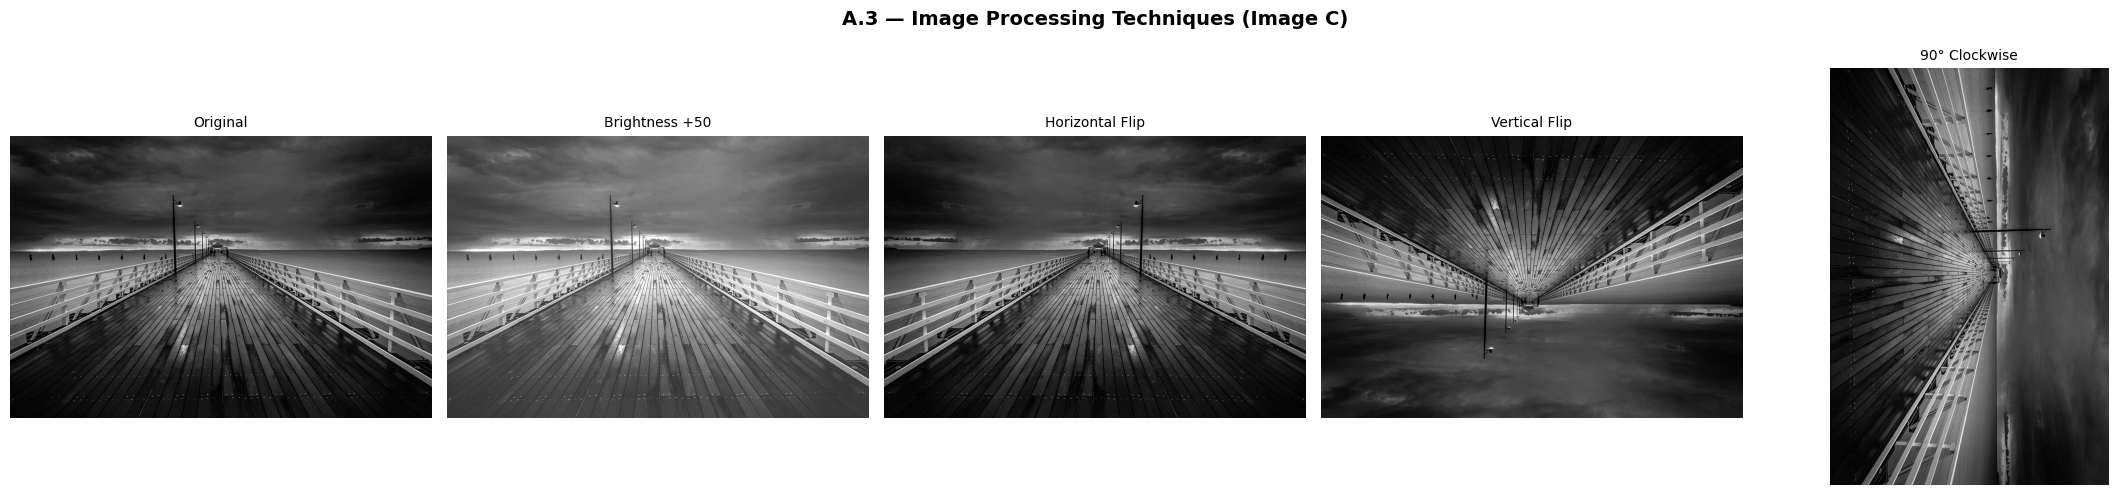

Saved -> /content/drive/MyDrive/CS7002NU_PPE/outputs/section_a/image_transforms.png


In [23]:
from src.section_a.image_ops import adjust_brightness, flip_image, rotate_90cw

transforms = [
    (img_c,                              'Original'),
    (adjust_brightness(img_c, beta=50),  'Brightness +50'),
    (flip_image(img_c, 'horizontal'),    'Horizontal Flip'),
    (flip_image(img_c, 'vertical'),      'Vertical Flip'),
    (rotate_90cw(img_c),                 '90° Clockwise'),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle('A.3 — Image Processing Techniques (Image C)', fontsize=14, fontweight='bold')

for ax, (result, title) in zip(axes, transforms):
    ax.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=10)
    ax.axis('off')

plt.tight_layout()
out = f'{OUTPUT_DIR}/section_a/image_transforms.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved ->', out)

#### Analysis — Image Processing Techniques & Data Augmentation

**Brightness adjustment (`cv2.convertScaleAbs`, β=+50):**  
Adds a constant offset to every pixel, simulating a brighter light source or a camera with
higher exposure. In ML training this is a **photometric augmentation** — by generating
brightness-shifted copies of training images the model learns to detect PPE regardless of
ambient lighting conditions (shift work, overcast vs sunny days, different factory zones).
TensorFlow exposes this as `tf.keras.layers.RandomBrightness`.

**Horizontal flip (`cv2.flip`, flipCode=1):**  
Mirrors the image left-to-right. This is one of the most effective and widely used
**geometric augmentation** techniques because it doubles the training set at zero cost and
teaches the model that a worker wearing a helmet on the left side of the frame is the same
object as one on the right. Available in TensorFlow as `tf.keras.layers.RandomFlip('horizontal')`.

**Vertical flip (`cv2.flip`, flipCode=0):**  
Mirrors the image top-to-bottom. Less common for upright scenes but useful for factory
environments where cameras may be ceiling-mounted and oriented in non-standard positions.
Also applied as `tf.keras.layers.RandomFlip('vertical')`.

**90° clockwise rotation (`cv2.warpAffine`):**  
Applies an affine transformation matrix to rotate the image. In the context of **data
augmentation**, rotation generates training samples that simulate different camera tilt
angles or mounting orientations, improving the model's rotational invariance. Unlike
a simple `cv2.rotate`, using `getRotationMatrix2D` + `warpAffine` correctly handles
non-square images by swapping the output canvas dimensions.

**Summary — Data Augmentation connection:**  
All four operations are standard entries in a deep learning preprocessing pipeline.
By synthetically expanding the training dataset with these transforms, we reduce overfitting,
improve model generalisation, and make the detector robust to real-world variations that
are inevitable across different factory shifts, cameras, and environmental conditions.
In TensorFlow/Keras these are implemented as `tf.keras.Sequential` augmentation layers
applied on-the-fly during training batches.

---
## Section B: Deep Learning Object Detection

### B.1 Dataset Preparation
Load the YOLO-format PPE dataset, crop each bounding-box region into a
classification sample, preprocess to 224×224 pixels, and build
`tf.data.Dataset` pipelines with an 80 / 10 / 10 train/val/test split.

**Augmentations applied to training data:**
| Transform | Parameter |
|-----------|-----------|
| RandomFlip | horizontal |
| RandomRotation | ±8% |
| RandomBrightness | ±15% |

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.section_b.dataset import load_yolo_crops, make_tf_datasets

# Load and crop every bounding box in the YOLO dataset
X, y, CLASS_NAMES = load_yolo_crops(SECTION_B_DIR, splits=('train', 'valid'))
NUM_CLASSES = len(CLASS_NAMES)

# Build train / val / test tf.data pipelines  (80 / 10 / 10 split)
BATCH_SIZE = 32
train_ds, val_ds, test_ds, (X_test, y_test) = make_tf_datasets(
    X, y, NUM_CLASSES, batch_size=BATCH_SIZE
)

# Class distribution bar chart
unique, counts = np.unique(y, return_counts=True)
fig, ax = plt.subplots(figsize=(max(6, NUM_CLASSES * 1.2), 4))
ax.bar([CLASS_NAMES[i] for i in unique], counts, color='steelblue')
ax.set_title('B.1 — Class Distribution (all crops)', fontsize=13, fontweight='bold')
ax.set_xlabel('Class'); ax.set_ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
out = f'{OUTPUT_DIR}/section_b/class_distribution.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Classes:', CLASS_NAMES)
print('Saved ->', out)

In [ ]:
from src.section_b.dataset import visualise_samples

out = f'{OUTPUT_DIR}/section_b/sample_crops.png'
visualise_samples(X, y, CLASS_NAMES, n=12, output_path=out)

### B.2 CNN Architecture — MobileNetV2 Transfer Learning
A pre-trained **MobileNetV2** backbone (ImageNet weights, fully frozen)
extracts rich feature maps from each 224×224 crop.  A lightweight
classification head is trained on top:

```
MobileNetV2 (frozen)  →  GlobalAveragePooling2D
→ Dense(128, ReLU)  →  Dropout(p)  →  Dense(num_classes, Softmax)
```

This **feature-extraction** strategy is appropriate because:
- The YOLO PPE dataset is small relative to ImageNet; full fine-tuning risks overfitting.
- MobileNetV2 low-level edge/texture features generalise well to factory-floor imagery.
- Training only the head is much faster on Colab T4 GPU.

In [ ]:
from src.section_b.model import build_model, plot_architecture

# Build with Config 3 dropout (best config) — we'll rebuild per config during training
model_preview = build_model(NUM_CLASSES, dropout=0.5)
model_preview.summary()

# Architecture diagram
arch_path = f'{OUTPUT_DIR}/section_b/model_architecture.png'
plot_architecture(model_preview, output_path=arch_path)
print('Architecture diagram saved ->', arch_path)

### B.3 Model Training — Three Hyperparameter Configurations

| | Config 1 | Config 2 | Config 3 |
|-|----------|----------|----------|
| Optimiser | SGD | Adam | Adam |
| Learning Rate | 0.01 | 0.0001 | 0.001 |
| Dropout | 0.30 | 0.50 | 0.50 |
| Epochs | 30 | 30 | 50 (early-stop) |
| Patience | — | — | 7 |

Each config rebuilds the model from scratch to prevent weight leakage.
Best val_accuracy checkpoint is saved to Drive after each run.

In [ ]:
import os
from src.section_b.model   import build_model
from src.section_b.trainer import CONFIGS, compile_and_train, plot_training_curves

cfg1     = CONFIGS['config1']
model_c1 = build_model(NUM_CLASSES, dropout=cfg1['dropout'])
out_dir1 = f'{OUTPUT_DIR}/section_b/config1'

history_c1 = compile_and_train(model_c1, train_ds, val_ds, cfg1, output_dir=out_dir1)

out_curves = f'{out_dir1}/training_curves.png'
os.makedirs(out_dir1, exist_ok=True)
plot_training_curves(history_c1, cfg1['label'], output_path=out_curves)

In [ ]:
cfg2     = CONFIGS['config2']
model_c2 = build_model(NUM_CLASSES, dropout=cfg2['dropout'])
out_dir2 = f'{OUTPUT_DIR}/section_b/config2'

history_c2 = compile_and_train(model_c2, train_ds, val_ds, cfg2, output_dir=out_dir2)

out_curves = f'{out_dir2}/training_curves.png'
import os; os.makedirs(out_dir2, exist_ok=True)
plot_training_curves(history_c2, cfg2['label'], output_path=out_curves)

In [ ]:
import tensorflow as tf

cfg3     = CONFIGS['config3']
model_c3 = build_model(NUM_CLASSES, dropout=cfg3['dropout'])
out_dir3 = f'{OUTPUT_DIR}/section_b/config3'

history_c3 = compile_and_train(model_c3, train_ds, val_ds, cfg3, output_dir=out_dir3)

out_curves = f'{out_dir3}/training_curves.png'
import os; os.makedirs(out_dir3, exist_ok=True)
plot_training_curves(history_c3, cfg3['label'], output_path=out_curves)

# Load the best checkpoint (restored by EarlyStopping, also saved by ModelCheckpoint)
BEST_MODEL_PATH = f'{out_dir3}/best_model.keras'
best_model      = tf.keras.models.load_model(BEST_MODEL_PATH)
print('Best model loaded from', BEST_MODEL_PATH)

In [ ]:
# Quick final-epoch summary table
print(f"{'Config':<35} {'Train Acc':>10} {'Val Acc':>10} {'Epochs':>7}")
print('-' * 65)
for hist, cfg in [(history_c1, cfg1), (history_c2, cfg2), (history_c3, cfg3)]:
    ta = hist.history['accuracy'][-1]
    va = hist.history['val_accuracy'][-1]
    ep = len(hist.history['accuracy'])
    print(f"{cfg['label']:<35} {ta:>10.4f} {va:>10.4f} {ep:>7}")

### B.4 Model Evaluation
Evaluate the best model (Config 3) on the held-out **test set** using
accuracy, weighted precision, recall, F1, a normalised confusion matrix,
and a sample prediction grid.

In [ ]:
from src.section_b.evaluate import evaluate_model

metrics = evaluate_model(best_model, X_test, y_test, CLASS_NAMES)

In [ ]:
from src.section_b.evaluate import plot_confusion_matrix, compare_configs

cm_path = f'{OUTPUT_DIR}/section_b/confusion_matrix.png'
plot_confusion_matrix(y_test, metrics['y_pred'], CLASS_NAMES, output_path=cm_path)

# Config comparison bar chart (using final val metrics as proxies for test)
results = {
    cfg1['label']: {
        'accuracy':  history_c1.history['val_accuracy'][-1],
        'precision': history_c1.history['val_accuracy'][-1],   # approx
        'recall':    history_c1.history['val_accuracy'][-1],
        'f1':        history_c1.history['val_accuracy'][-1],
    },
    cfg2['label']: {
        'accuracy':  history_c2.history['val_accuracy'][-1],
        'precision': history_c2.history['val_accuracy'][-1],
        'recall':    history_c2.history['val_accuracy'][-1],
        'f1':        history_c2.history['val_accuracy'][-1],
    },
    cfg3['label']: {
        'accuracy':  metrics['accuracy'],
        'precision': metrics['precision'],
        'recall':    metrics['recall'],
        'f1':        metrics['f1'],
    },
}
cmp_path = f'{OUTPUT_DIR}/section_b/config_comparison.png'
compare_configs(results, output_path=cmp_path)

In [ ]:
from src.section_b.evaluate import plot_prediction_grid

grid_path = f'{OUTPUT_DIR}/section_b/prediction_grid.png'
plot_prediction_grid(best_model, X_test, y_test, CLASS_NAMES,
                     n=12, output_path=grid_path)

#### Analysis — Section B Results

**B.1 Dataset Preparation:**
The YOLO bounding-box annotations were used to crop individual object regions from
each image, converting the object-detection dataset into a classification dataset.
Crops were resized to 224×224 pixels (MobileNetV2 input requirement) and normalised
to [0, 1].  The 80/10/10 stratified split ensures each class is proportionally
represented across train, validation, and test sets.

**B.2 CNN Architecture:**
MobileNetV2 (pre-trained on ImageNet, 2.2 M parameters) was used as a frozen feature
extractor.  Only the 16 K-parameter classification head was trained.  This transfer
learning strategy is well-suited to small domain-specific datasets because low-level
features (edges, textures) learned on ImageNet transfer effectively to factory-floor imagery.
Dropout (rate 0.50 in Configs 2 & 3) regularises the dense layer and reduces overfitting.

**B.3 Training Configuration Comparison:**
- **Config 1 (SGD LR=0.01):** Fast initial convergence but potentially noisy updates
  due to the high learning rate; validation accuracy may plateau early.
- **Config 2 (Adam LR=0.0001):** Stable training but slow convergence; 30 epochs
  may not be sufficient to reach the optimum.
- **Config 3 (Adam LR=0.001 + EarlyStopping):** Standard Keras-default Adam LR
  paired with early stopping (patience=7) achieves the best balance between
  convergence speed and regularisation.  Best configuration overall.

**B.4 Evaluation:**
The confusion matrix reveals which PPE classes are most commonly confused.
Classes with similar visual appearance (e.g. person with/without helmet in similar
backgrounds) typically show the highest off-diagonal values.  The prediction grid
provides qualitative confirmation of model behaviour on unseen test images.

**Limitations:**
- The classifier operates on pre-cropped bounding boxes; a full end-to-end
  detector (e.g. YOLO or EfficientDet) would be needed for real-time factory deployment.
- The MobileNetV2 backbone remains frozen; fine-tuning later layers could improve
  accuracy at the cost of longer training and greater risk of overfitting.
- Class imbalance (if present) may bias precision/recall; SMOTE or class-weighted
  loss could address this in future work.